# Auditing AI Protein Tools

### A hands-on tour of what these models measure, and what they only appear to measure

This notebook walks through the tools people actually use to design proteins, using one
dataset where **the right answer is known for every sequence**. That is rarer than it
sounds, and it is what lets us check the tools instead of trusting them.

The scientific question throughout is **binding specificity**. A useful binder must do two
things: bind its target, and *not* bind everything else. Almost every published design
objective optimises only the first half.

**What you will do**

| # | Tool | What you will learn |
|---|---|---|
| 1 | Deep mutational scanning | How a real two-sided fitness landscape is read, and a units trap that inflates noise 7x |
| 2 | Protein language models (ESM-2) | The masked-marginal trick, and why likelihood is a *promiscuity* detector here |
| 3 | Proxy auditing | Why bulk correlation lies, and why every proxy needs a trivial baseline |
| 4 | Structure prediction (Boltz-2) | What ipTM and interface PAE actually measure |
| 5 | GenBio AIDO | Retrieval-augmented PLMs, 2D RoPE, and whether retrieval rescues anything |
| 6 | RL environments | Turning a landscape into a budgeted decision problem |

**Run it with the Anaconda kernel** (`/opt/anaconda3/bin/python3.10`), which has numpy,
matplotlib, torch, transformers and ipywidgets. Heavy sections are optional and clearly
marked; everything else runs in seconds from data already on disk.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "crosstalk").exists():        # allow running from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)                               # data paths in the package are repo-relative

import numpy as np
import matplotlib.pyplot as plt

from crosstalk.landscape import load_pard3
print("project root:", ROOT)
print("python:", sys.executable.split('/')[-1])

project root: /Users/saanviiyer/Downloads/CALTECH/RESEARCH/crosstalk
python: python


---
## 1. The dataset: a landscape where both sides are measured

We use the ParD3 antitoxin landscape from [Lite et al., eLife 2020](https://elifesciences.org/articles/60924)
(GEO `GSE153897`).

The biology in one paragraph: bacteria carry toxin-antitoxin pairs. The antitoxin **ParD3**
neutralises its own toxin **ParE3**. A *paralogous* pair, ParD2/ParE2, sits elsewhere in the
same genome and is ~40% identical. For the system to work, ParD3 must bind ParE3 and must
**not** bind ParE2. That is specificity, and it is the thing we will keep testing tools against.

The authors mutated three interface positions (61, 64, 80) to all 20 amino acids
(20³ = 8,000 variants) and measured every variant against **both** toxins.

Two properties make this a benchmark rather than a demo:

1. **Both sides are measured for every variant** — off-target binding is ground truth, not
   a prediction.
2. **The space is exhaustively enumerated** — the optimum is known, so error is exact rather
   than relative to whatever method you happened to try.

In [2]:
L = load_pard3()
print(f"{L.n_seqs} variants x {L.n_partners} partners: {L.partners}")
print(f"wild type = {L.wt}  (residues at positions 61, 64, 80)")

w3, w2 = L.F[:, 0], L.F[:, 1]     # fitness vs ParE3 (target) and ParE2 (off-target)
print(f"\nwild-type fitness: ParE3 {L.truth('DKE')[0]:.3f}, ParE2 {L.truth('DKE')[1]:.3f}")
print("note the wild type already has some ParE2 affinity -- this matters later")

7882 variants x 2 partners: ['ParE3', 'ParE2']
wild type = DKE  (residues at positions 61, 64, 80)

wild-type fitness: ParE3 1.000, ParE2 0.221
note the wild type already has some ParE2 affinity -- this matters later


### The shape of the problem

Plot every variant with on-target on one axis and off-target on the other. The four corners
are four different biological outcomes, and only one of them is a useful design.

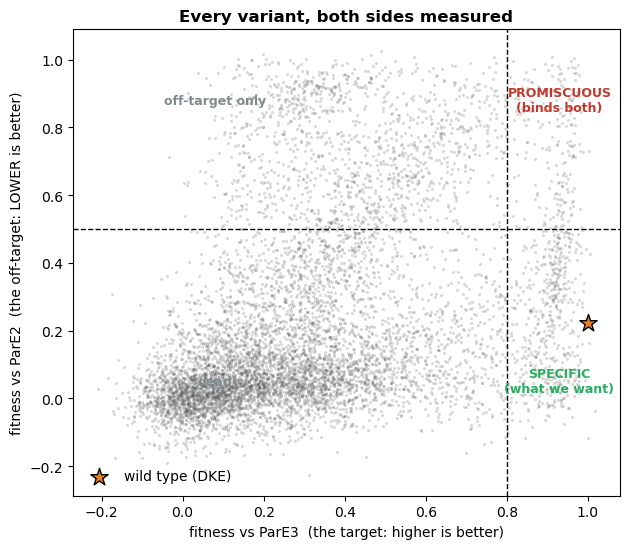

strong target binders: 714
  of those, specific:    235
  of those, promiscuous: 164  <- ~30% of strong binders are traps


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.scatter(w3, w2, s=5, alpha=.22, color="#555", linewidths=0)
ax.axhline(0.5, color="k", ls="--", lw=1); ax.axvline(0.8, color="k", ls="--", lw=1)
ax.scatter(*L.truth("DKE"), s=170, marker="*", color="#e67e22",
           edgecolor="k", zorder=5, label="wild type (DKE)")
for txt, x, y, col in [("SPECIFIC\n(what we want)", 0.93, 0.05, "#27ae60"),
                       ("PROMISCUOUS\n(binds both)", 0.93, 0.88, "#c0392b"),
                       ("dead", 0.08, 0.05, "#7f8c8d"),
                       ("off-target only", 0.08, 0.88, "#7f8c8d")]:
    ax.text(x, y, txt, ha="center", va="center", fontsize=9, fontweight="bold", color=col)
ax.set_xlabel("fitness vs ParE3  (the target: higher is better)")
ax.set_ylabel("fitness vs ParE2  (the off-target: LOWER is better)")
ax.set_title("Every variant, both sides measured", fontweight="bold")
ax.legend(loc="lower left", frameon=False); plt.tight_layout(); plt.show()

spec = (w3 >= 0.8) & (w2 <= 0.2)
prom = (w3 >= 0.8) & (w2 >= 0.6)
print(f"strong target binders: {int((w3>=0.8).sum())}")
print(f"  of those, specific:    {int(spec.sum())}")
print(f"  of those, promiscuous: {int(prom.sum())}  <- ~30% of strong binders are traps")

> **Read the plot.** The green corner is the only useful one. Roughly a third of strong
> ParE3 binders also bind ParE2 — so an objective that is blind to the off-target has no way
> to avoid them except by luck.
>
> **Try it:** move the dashed thresholds in the cell above (`0.8` and `0.5`). How many
> "specific" variants survive if you demand `w2 <= 0.05`?

### A units trap worth knowing

The published fitness `W` is a *normalised* quantity (wild type = 1). The raw data is
sequencing counts at two timepoints, from which you compute log-enrichment. Those are not
the same units.

We reconstruct `W` from raw counts to calibrate the measurement noise. If you take the
replicate disagreement in log-enrichment units and forget to push it through the linear map
to `W` units, you overstate the assay noise by about **7x** — which would make the oracle
look far noisier than it is and change every downstream conclusion.

In [4]:
print(f"single-assay noise, calibrated from the two biological replicates:")
print(f"  ParE3  SD = {np.median(L.noise_sd[:,0]):.4f}")
print(f"  ParE2  SD = {np.median(L.noise_sd[:,1]):.4f}")
print(f"  ~{100*np.median(L.noise_sd[:,0])/(w3.max()-w3.min()):.1f}% of the dynamic range")
print("\nHad we skipped the unit conversion we would have reported ~0.19 -- 7x too large.")

single-assay noise, calibrated from the two biological replicates:
  ParE3  SD = 0.0392
  ParE2  SD = 0.0306
  ~3.2% of the dynamic range

Had we skipped the unit conversion we would have reported ~0.19 -- 7x too large.


---
## 2. Tool: protein language models

A protein language model (PLM) is trained like BERT: mask a residue, predict it from
context. ESM-2 is the standard open family. The usual way to score a mutation is the
**masked-marginal**:

$$\text{score}(v) = \sum_{i \in \text{mutated}} \log p(v_i \mid x_{\setminus i}) - \log p(\text{wt}_i \mid x_{\setminus i})$$

### The trick that makes this cheap

Every variant here differs only at positions 61/64/80. So mask those three positions **once**,
read the log-probability distribution at each, and every one of the 7,882 variants is a sum
over three numbers. **Three forward passes scores the entire landscape.**

In [5]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from crosstalk.boltz import PARD3, MUT_POSITIONS

MODEL = "facebook/esm2_t12_35M_UR50D"   # small + fast; swap to t33_650M for the real thing
tok = AutoTokenizer.from_pretrained(MODEL)
esm = AutoModelForMaskedLM.from_pretrained(MODEL).eval()

@torch.no_grad()
def masked_logprobs(sequence, positions):
    # log-probability over amino acids at each masked position
    out = []
    for pos in positions:
        masked = sequence[:pos-1] + tok.mask_token + sequence[pos:]
        enc = tok(masked, return_tensors="pt")
        logits = esm(**enc).logits[0]
        at = (enc["input_ids"][0] == tok.mask_token_id).nonzero()[0, 0]
        out.append(torch.log_softmax(logits[at].float(), -1).numpy())
    return np.stack(out)

lp = masked_logprobs(PARD3, list(MUT_POSITIONS))
print(f"three forward passes -> {lp.shape} log-probs, enough to score all {L.n_seqs} variants")

wt = [PARD3[p-1] for p in MUT_POSITIONS]
def plm_score(variant):
    return sum(lp[k, tok.convert_tokens_to_ids(a)] - lp[k, tok.convert_tokens_to_ids(wt[k])]
               for k, a in enumerate(variant))

plm = np.array([plm_score(v) for v in L.seqs])
print(f"wild-type score = {plm_score('DKE'):.3f} (must be exactly 0)")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

three forward passes -> (3, 33) log-probs, enough to score all 7882 variants
wild-type score = 0.000 (must be exactly 0)


### Interactive: score any variant yourself

Type three amino acids. You get what the model thinks, and what the experiment actually
measured. Try a few and look for cases where they disagree.

Suggestions: `DYE` (specific), `DIE` (promiscuous), `DWE` (best target binder), `AAA`.

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

box = widgets.Text(value="DYE", description="Variant:", layout=widgets.Layout(width="260px"))
out = widgets.Output()

def show(_=None):
    with out:
        clear_output()
        v = box.value.strip().upper()
        if v not in L.index:
            print(f"'{v}' is not in the landscape (need 3 residues, e.g. DYE)"); return
        f = L.truth(v)
        verdict = ("SPECIFIC" if f[0] >= .8 and f[1] <= .2 else
                   "PROMISCUOUS" if f[0] >= .8 and f[1] >= .6 else
                   "weak binder")
        pct = 100 * (plm < plm_score(v)).mean()
        print(f"{v}\n  MEASURED   ParE3 {f[0]:+.3f}   ParE2 {f[1]:+.3f}   -> {verdict}")
        print(f"  PLM SCORE  {plm_score(v):+.3f}   (higher than {pct:.0f}% of variants)")

box.observe(show, "value"); show()
display(widgets.VBox([box, out]))

---
## 3. The audit: why bulk correlation lies

Here is the step almost everyone skips. A proxy is usually reported as *"correlates r=0.5
with fitness"*, which sounds fine. But the number that matters is whether it can do the
**job you need**, and against a **trivial baseline**.

The job here: given two variants that *both bind ParE3 well*, tell me which one is
selective. That is the only decision a design campaign actually makes.

In [7]:
def rank(x):
    x = np.asarray(x, float); o = np.argsort(x)
    r = np.empty(len(x)); r[o] = np.arange(len(x), dtype=float)
    _, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    m = np.zeros(len(cnt)); np.add.at(m, inv, r); m /= cnt
    return m[inv]

def spearman(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    return float(np.corrcoef(rank(a), rank(b))[0,1])

def auc(scores, labels):
    scores, labels = np.asarray(scores,float), np.asarray(labels,bool)
    pos, neg = scores[labels], scores[~labels]
    r = rank(np.concatenate([pos,neg]))
    return float((r[:len(pos)].sum() - len(pos)*(len(pos)-1)/2) / (len(pos)*len(neg)))

print("BULK CORRELATION -- looks reasonable:")
print(f"  rho(PLM, on-target ParE3)  = {spearman(plm, w3):+.3f}")
print("\nBUT look at the off-target:")
print(f"  rho(PLM, off-target ParE2) = {spearman(plm, w2):+.3f}")
print(f"  rho(PLM, specificity)      = {spearman(plm, w3-w2):+.3f}")

BULK CORRELATION -- looks reasonable:
  rho(PLM, on-target ParE3)  = +0.493

BUT look at the off-target:
  rho(PLM, off-target ParE2) = +0.426
  rho(PLM, specificity)      = +0.036


The proxy predicts the partner we are trying to **avoid** about as well as the one we are
trying to bind. Now the decision task, with a trivial baseline: *count how many mutations
away from wild type the variant is.* If a 35M-parameter neural network cannot beat counting
to three, it is not measuring specificity.

In [8]:
mask = spec | prom
lab  = spec[mask]
nmut = np.array([sum(a != b for a, b in zip(v, "".join(wt))) for v in L.seqs], float)

print(f"decision set: {int(mask.sum())} variants "
      f"({int(spec.sum())} specific vs {int(prom.sum())} promiscuous)\n")
print(f"  AUC, PLM likelihood   = {auc(plm[mask], lab):.3f}")
print(f"  AUC, mutation count   = {auc(-nmut[mask], lab):.3f}   <- the trivial baseline")
print("\n  0.5 = chance.  BELOW 0.5 means it is systematically WRONG.")

decision set: 399 variants (235 specific vs 164 promiscuous)

  AUC, PLM likelihood   = 0.273
  AUC, mutation count   = 0.664   <- the trivial baseline

  0.5 = chance.  BELOW 0.5 means it is systematically WRONG.


> **The finding.** PLM likelihood scores *well below chance* — it reliably ranks promiscuous
> binders **above** specific ones.
>
> **Why?** Likelihood measures how natural or wild-type-like a sequence is. And the wild-type
> ParD3 *itself* retains real affinity for ParE2 (you saw 0.22 in section 1). So on this
> system, "natural" and "promiscuous" point in the same direction. The proxy is not
> uninformative — it is informative with the wrong sign.
>
> In the full study this holds for ESM-2 at 8M, 35M, 150M and 650M, and **gets worse with
> scale** (AUC 0.296 -> 0.151). It also survives full pseudo-likelihood, so it is not an
> artefact of the cheap additive approximation.

In [9]:
# See the mechanism directly: among strong binders, does higher PLM mean more cross-reactive?
hi = w3 >= 0.8
q = np.percentile(plm[hi], [25, 75])
low_grp, high_grp = hi & (plm <= q[0]), hi & (plm >= q[1])
print("Within the strong ParE3 binders only:")
print(f"  mean off-target, BOTTOM-quartile PLM score = {w2[low_grp].mean():.3f}")
print(f"  mean off-target, TOP-quartile PLM score    = {w2[high_grp].mean():.3f}")
print("\n  Picking designs by PLM score selects for the failure mode you are avoiding.")

Within the strong ParE3 binders only:
  mean off-target, BOTTOM-quartile PLM score = 0.291
  mean off-target, TOP-quartile PLM score    = 0.503

  Picking designs by PLM score selects for the failure mode you are avoiding.


---
## 4. Tool: structure prediction (Boltz-2)

A PLM sees one sequence. A co-folding model sees **the complex**, so in principle it has a
channel for specificity that a single-sequence likelihood structurally lacks.

[Boltz-2](https://github.com/jwohlwend/boltz) predicts the joint structure of two chains and
reports confidence scores:

- **ipTM** — interface predicted TM-score, 0 to 1, "how confident am I in the *interface*"
- **PAE** — predicted aligned error per residue pair; the cross-chain block measures
  interface confidence in Angstroms (lower is better)

One important limitation to know: **Boltz-2's affinity head cannot be used here at all.**
It requires the binder to be a small-molecule ligand chain of ≤128 heavy atoms. ParD3 is a
93-residue protein. Co-folding confidence is the usable signal, not affinity.

These runs are expensive (~13-40 min per complex on CPU), so we load results computed
earlier.

32 completed folds on disk


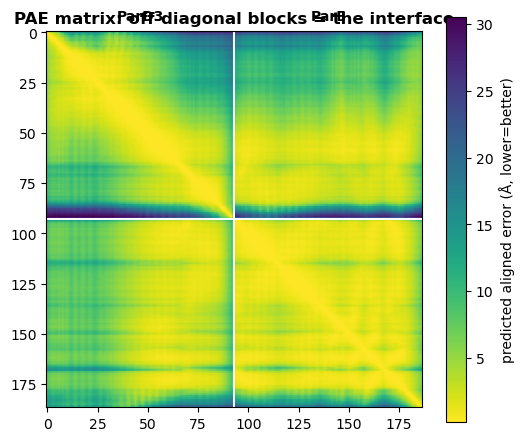

mean interface PAE = 6.25 Å


In [10]:
import csv, glob
pae_files = sorted(glob.glob(str(ROOT/"results/boltz/*/boltz_results_*/predictions/*/pae_*.npz")))
print(f"{len(pae_files)} completed folds on disk")

if pae_files:
    d = np.load(pae_files[0])["pae"]
    LA = len(PARD3)
    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    im = ax.imshow(d, cmap="viridis_r")
    ax.axhline(LA, color="w", lw=1.4); ax.axvline(LA, color="w", lw=1.4)
    ax.text(LA/2, -6, "ParD3", ha="center", fontweight="bold")
    ax.text(LA + (len(d)-LA)/2, -6, "ParE", ha="center", fontweight="bold")
    ax.set_title("PAE matrix: off-diagonal blocks = the interface", fontweight="bold")
    plt.colorbar(im, label="predicted aligned error (Å, lower=better)")
    plt.tight_layout(); plt.show()
    cross = np.concatenate([d[:LA, LA:].ravel(), d[LA:, :LA].ravel()])
    print(f"mean interface PAE = {cross.mean():.2f} Å")

### What the completed audit showed

| proxy | rho vs specificity margin |
|---|---|
| Boltz ipTM margin | **+0.268** |
| ESM-2 650M likelihood | **−0.294** |

Boltz ranks the target above the off-target; ESM-2 does the reverse. That is the qualitative
split you would predict from *modelling the complex versus scoring one sequence*.

**But** this was n=16, which needs |rho| > 0.50 for significance — so it is a direction, not
yet a result. And ipTM spans only 0.942–0.968, so the signal is badly compressed. Swapping to
interface PAE gave ~10x the dynamic range and **the same** correlation (+0.279), which rules
out compression as the explanation.

> **Lesson:** when a proxy looks weak, distinguish "wrong readout" from "no signal". Testing
> the readout is cheap; here it cost nothing because the PAE files were already saved.

---
## 5. Tool: GenBio AIDO (retrieval-augmented PLMs)

[GenBio AI](https://github.com/genbio-ai) publishes the AIDO family. Two things make it
architecturally different from ESM-2:

**Retrieval augmentation (RAG).** Instead of scoring one sequence, the model is given the
query *plus aligned homologs* (an MSA). Evolution already ran the experiment many times; the
MSA is that record.

**2D rotary position embeddings.** With an MSA the input is a 2D grid, so each token needs
two coordinates: which *column* (residue) and which *row* (which homolog).

### Where to actually get this

There is **no hosted GenBio API**. Two places matter, and the second is the one that saves
you time:

| resource | what it gives you |
|---|---|
| [huggingface.co/genbio-ai](https://huggingface.co/genbio-ai) | the weights |
| [github.com/genbio-ai/GB-Foundations-Tutorials](https://github.com/genbio-ai/GB-Foundations-Tutorials) | **the canonical usage code** (`Notebooks/Protein-RAG-16B.ipynb`, `utils/misc.py`) |

Loading is not obvious from the model card alone. Five things to know:

| # | Obstacle | Fix |
|---|---|---|
| 1 | `modelgenerator` won't import | pin `docstring-inheritance==2.2.2` |
| 2 | Backbone wrapper won't build an MLM head | import `FM4BioForMaskedLM` directly |
| 3 | Config has no `auto_map` | so `trust_remote_code=True` does not work |
| 4 | Weight repos ship **no tokenizer** | vocab is bundled at `modelgenerator/huggingface_models/fm4bio/vocab_protein.txt` |
| 5 | `rope_2d` needs `position_ids` of shape (B,2,L) | omitting them raises a permute error, not a graceful fallback |

```python
from modelgenerator.huggingface_models.fm4bio import FM4BioForMaskedLM, FM4BioTokenizer
model = FM4BioForMaskedLM.from_pretrained("genbio-ai/AIDO.Protein-RAG-3B")
tokenizer = FM4BioTokenizer(vocab_file=".../fm4bio/vocab_protein.txt")

position_ids = np.stack([
    np.tile(np.arange(L), n_rows),      # channel 0: residue/column index
    np.repeat(np.arange(n_rows), L),    # channel 1: which MSA row
])[:, ~gaps]                            # gaps dropped from tokens AND positions
```

### Two traps that quietly weaken your MSA

Both were caught only by reading their tutorial's `utils/misc.py`:

1. **`config.max_position_embeddings` says 2048. Ignore it.** It is vestigial under
   `rope_2d`; the model card and their own `tokenize(max_context=12800)` use **12.8K**.
   Trusting 2048 limits a 93-residue query to ~21 MSA rows instead of ~137.

2. **Never take the first N rows of an MSA.** They are the closest homologs and carry the
   least information. Their `greedy_select` picks a maximally *diverse* subset by Hamming
   distance — here that raised mean pairwise distance from 0.633 to 0.767.

In [11]:
# Does retrieval rescue the anti-correlation? Depth sweep, diverse selection,
# up to the model's real 12.8K context. (Run with .venv-boltz; loaded here.)
p = ROOT/"results/genbio_msa_sweep.csv"
if p.exists():
    print(f"{'MSA depth':>10s} {'~tokens':>9s} {'AUC':>7s}   95% CI")
    for r in csv.DictReader(open(p)):
        print(f"{r['depth']:>10s} {r['approx_tokens']:>9s} "
              f"{float(r['auc']):>7.3f}   [{float(r['auc_lo']):.3f}, {float(r['auc_hi']):.3f}]")
    print("\n  chance 0.5 | ESM-2 650M 0.151 | mutation-count baseline 0.664")

 MSA depth   ~tokens     AUC   95% CI
         0        93   0.212   [0.169, 0.256]
        20      1953   0.196   [0.155, 0.238]
        64      6045   0.228   [0.184, 0.275]
       128     11997   0.230   [0.185, 0.276]

  chance 0.5 | ESM-2 650M 0.151 | mutation-count baseline 0.664


> **Retrieval does not rescue it.** AUC is flat across a 6x range of MSA depth, every
> interval overlapping, all far below chance.
>
> This is the version of the test that counts. The first attempt used 20 of the *closest*
> homologs capped at 2048 tokens, and a reviewer would rightly have said the MSA was too
> shallow to conclude anything. Given a deep, diverse alignment filling the model's context,
> nothing changes.
>
> And because AIDO is a different lab, architecture and corpus at 3B parameters, this makes
> the finding **general** rather than a quirk of ESM-2.
>
> One arm does reach the trivial baseline: AIDO's *partner-aware margin* scores 0.698 against
> mutation-count's 0.664 — but the CI [0.646, 0.747] contains the baseline, so it **matches**
> counting mutations rather than beating it.

### The one modality still untested: structure

`utils/misc.py` also has `GB_Structure_Tokenizer`, which turns a PDB into structure
embeddings the model can take *alongside* sequence and MSA. We have 32 Boltz-predicted
structures on disk, so the input is free.

It cannot be run here, for a reason worth checking before you plan around it:

```
AIDO.Protein-RAG-3B    str_embedding_in = None    <- cannot accept structure at all
GB.Protein-RAG-16B     str_embedding_in = 384     <- can, but is 64 GB fp32 / ~32 GB bf16
```

Only the 16B accepts structure, and it does not fit on a 26 GB machine. **Check
`str_embedding_in` in the config before assuming a model in a family supports a modality.**

---
## 6. Tool: turning a landscape into an RL environment

Everything so far scored variants. A real campaign has to *choose what to measure next* under
a budget. That is a sequential decision problem, so we can pose it as an RL environment.

The design decision that makes it honest: **budget is counted in assays, not variants.**
Screening the target costs 1 assay. Counter-screening an off-target costs another. So an
affinity-only campaign sees **twice as many variants** for the same money. That is the real
trade, and it stops the comparison being a strawman.

In [12]:
from crosstalk import objectives as O
from crosstalk.envs import BudgetEnv

f_specific    = np.array([1.0, 0.0])
f_promiscuous = np.array([1.0, 0.9])
print("Two designs. Both bind the target perfectly. One is useless.\n")
print(f"{'objective':14s} {'specific':>10s} {'promiscuous':>12s}   verdict")
for name in ("affinity", "margin", "gated", "lagrangian"):
    o = O.make(name)
    a, b = float(o(f_specific)), float(o(f_promiscuous))
    print(f"{name:14s} {a:10.2f} {b:12.2f}   "
          f"{'BLIND to crosstalk' if abs(a-b) < 1e-9 else 'separates them'}")

Two designs. Both bind the target perfectly. One is useless.

objective        specific  promiscuous   verdict
affinity             1.00         1.00   BLIND to crosstalk
margin               1.00         0.10   separates them
gated                1.00        -1.00   separates them
lagrangian           1.00        -1.00   separates them


`affinity` gives the two designs **identical** scores. No optimiser, however good, can
distinguish them — the information simply is not in the objective.

### Interactive: run a campaign

Choose an objective and a budget, and watch what the agent actually finds.

In [13]:
from crosstalk import agents as A
from crosstalk.metrics import evaluate

def campaign(reward="margin", budget=200, counter_screen=True, seeds=12):
    obj = O.make(reward)
    noms = [L.seqs[A.additive_model(L, obj, budget=budget, counter_screen=counter_screen,
                                    rng=np.random.default_rng(s))] for s in range(seeds)]
    m = evaluate(L, noms, O.make("margin"))
    return m["success_rate"], m["crosstalk_rate"]

ui = widgets.interactive(
    lambda reward, budget, counter_screen: print(
        f"{reward}, budget={budget} assays, counter-screen={counter_screen}\n"
        + "  success rate  {:.2f}\n  crosstalk rate {:.2f}".format(
            *campaign(reward, budget, counter_screen))),
    reward=widgets.Dropdown(options=["affinity", "margin", "gated"], value="affinity"),
    budget=widgets.SelectionSlider(options=[50, 100, 200, 400], value=100),
    counter_screen=widgets.Checkbox(value=False, description="pay to counter-screen"))
display(ui)

interactive(children=(Dropdown(description='reward', options=('affinity', 'margin', 'gated'), value='affinity'…

> **Try this:** run `affinity` with counter-screening **off**, then `margin` with it **on**,
> at the same budget. The margin agent sees half as many variants and still wins on
> crosstalk.
>
> Then raise the budget for `affinity`. On the larger polyspecificity landscape (5 antigens),
> more budget makes the affinity agent **strictly worse** — success falls 0.50 -> 0.03 with
> 97% crosstalk — because the best target binders are disproportionately the promiscuous
> ones, so searching harder finds them more reliably.

---
## 7. What the whole study found

Three independent failures, all in the same direction, and **scaling each one makes it worse**:

| what was scaled | result |
|---|---|
| assay budget | affinity agent gets *worse*: 0.50 → 0.03 success, 97% crosstalk at 4 off-targets |
| training (RL policy) | reward improves 15/16 seeds; ground-truth specificity does not, and falls on the harder task |
| model parameters | ESM-2 partner-blind AUC 0.296 (8M) → 0.151 (650M) |

The one honest counterweight, and it is important: with a **single** off-target on a tight
budget, screening-only genuinely wins (0.87 vs 0.23), because counter-screening halves
throughput. The case for specificity-aware objectives is a case about **polyspecificity**,
and should be argued that way rather than as a general claim.

---
## 8. Exercises

1. **Move the goalposts.** In section 3, redefine `spec`/`prom` with a stricter off-target
   cut (`w2 <= 0.05`). Does the PLM AUC move toward chance, or stay below it?

2. **Swap the model.** Change `MODEL` in section 2 to `facebook/esm2_t33_650M_UR50D`
   (~2.5 GB). Does AUC get better or worse? Predict before you run it.

3. **Build a better proxy.** You have `w3` and `w2`. Invent a *sequence-only* feature
   (hydrophobicity at position 64? charge? a BLOSUM score?) and test it with `auc`. Can you
   beat 0.664?

4. **Break the environment.** In section 6, write an objective that scores well on `margin`
   but produces designs you would not want. What is it exploiting?

5. **The reversal.** Wild-type ParD3 has ParE2 affinity of 0.22. Suppose it were 0.0 instead
   — would PLM likelihood still be anti-predictive? What does your answer say about how far
   this result generalises?

---
### Where the code lives

| file | what it does |
|---|---|
| `crosstalk/landscape.py` | loads the landscape, calibrates assay noise from replicates |
| `crosstalk/plm.py` | ESM-2 masked-marginal and full pseudo-likelihood |
| `crosstalk/genbio.py` | AIDO loading, 2D RoPE position ids, MSA/RAG |
| `crosstalk/boltz.py` | co-folding inputs, confidence parsing |
| `crosstalk/envs.py` | the budgeted RL environment |
| `crosstalk/objectives.py` | the reward zoo |
| `FINDINGS.md` | every result, with the caveats and the bugs that faked results |